This notebook's only job initially is:
Understand the dataset.

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [16]:
#Loading the raw excel file
data_path = "../data/raw/sorush_dataset.xlsx"

df = pd.read_excel(
    data_path,
    sheet_name="SorushField",
    skiprows=[0, 2],
    header=0,
    usecols="A:G"
)

print("Dataset shape:", df.shape)

Dataset shape: (7245, 7)


In [17]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Shape:
(7245, 7)

Columns:
['Sample #', 'Well', 'D (1/64in)', 'Pwh', 'γo', 'GLR', 'QL']

First 5 rows:


,Sample #,Well,D (1/64in),Pwh,γo,GLR,QL
0,1,SR-17,71.424,175.930730,1.063251,152,10853.696136
1,2,SR-17,71.424,176.075768,1.063251,152,11019.747120
2,3,SR-17,71.424,174.915466,1.063251,152,11125.415928
3,4,SR-17,71.424,175.785692,1.063251,152,11110.320384
4,5,SR-17,71.424,175.205542,1.063251,152,11095.224840



Last 5 rows:


,Sample #,Well,D (1/64in),Pwh,γo,GLR,QL
7240,7241,SR-26,41.216,440.624533,1.023322,118,6898.663608
7241,7242,SR-26,41.216,441.494759,1.023322,118,6913.759152
7242,7243,SR-26,41.216,442.655060,1.023322,118,6913.759152
7243,7244,SR-26,41.216,438.739042,1.023322,118,6913.759152
7244,7245,SR-26,41.216,439.754306,1.023322,118,6913.759152


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7245 entries, 0 to 7244
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Sample #    7245 non-null   int64  
 1   Well        7245 non-null   str    
 2   D (1/64in)  7245 non-null   float64
 3   Pwh         7245 non-null   float64
 4   γo          7245 non-null   float64
 5   GLR         7245 non-null   int64  
 6   QL          7245 non-null   float64
dtypes: float64(4), int64(2), str(1)
memory usage: 396.3 KB


In [22]:
print(df.isnull().sum())

Sample #      0
Well          0
D (1/64in)    0
Pwh           0
γo            0
GLR           0
QL            0
dtype: int64


In [23]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [24]:
print("Number of wells:", df["Well"].nunique())

print("\nWells:")
print(df["Well"].unique())

Number of wells: 10

Wells:
<StringArray>
['SR-17', 'SR-18', 'SR-19', 'SR-20', 'SR-21', 'SR-22', 'SR-23', 'SR-24',
 'SR-25', 'SR-26']
Length: 10, dtype: str


In [25]:
FEATURES = [
    "D (1/64in)",
    "Pwh",
    "γo",
    "GLR"
]

TARGET = "QL"

print("Features:")
for feature in FEATURES:
    print("-", feature)

print("\nTarget:")
print("-", TARGET)

Features:
- D (1/64in)
- Pwh
- γo
- GLR

Target:
- QL


In [26]:
X = df[FEATURES].copy()
y = df[TARGET].copy()
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7245, 4)
y shape: (7245,)


In [29]:
display(
    df[FEATURES + [TARGET]].describe().T
)
print("Minimum QL:", df["QL"].min())
print("Maximum QL:", df["QL"].max())
for feature in FEATURES:
    print(
        f"{feature}: "
        f"min={df[feature].min()}, "
        f"max={df[feature].max()}"
    )

,count,mean,std,min,25%,50%,75%,max
D (1/64in),7245.0,65.700624,15.217598,33.792000,54.016000,64.000000,71.936000,111.872000
Pwh,7245.0,318.513798,169.476577,130.533930,209.869552,261.067860,387.250659,1023.531049
γo,7245.0,0.995364,0.060510,0.929329,0.929329,1.032226,1.052297,1.070318
GLR,7245.0,135.325880,42.898960,3.000000,116.000000,129.000000,166.000000,217.000000
QL,7245.0,11666.705951,3624.781858,660.430050,9842.294688,11729.237688,13389.747528,23700.004080


Minimum QL: 660.43005
Maximum QL: 23700.00408
D (1/64in): min=33.792, max=111.87200000000001
Pwh: min=130.53393, max=1023.5310488999999
γo: min=0.9293286219081273, max=1.0703180212014134
GLR: min=3, max=217


Well
SR-17    814
SR-18    680
SR-19    779
SR-20    706
SR-21    657
SR-22    815
SR-23    806
SR-24    856
SR-25    619
SR-26    513
Name: count, dtype: int64

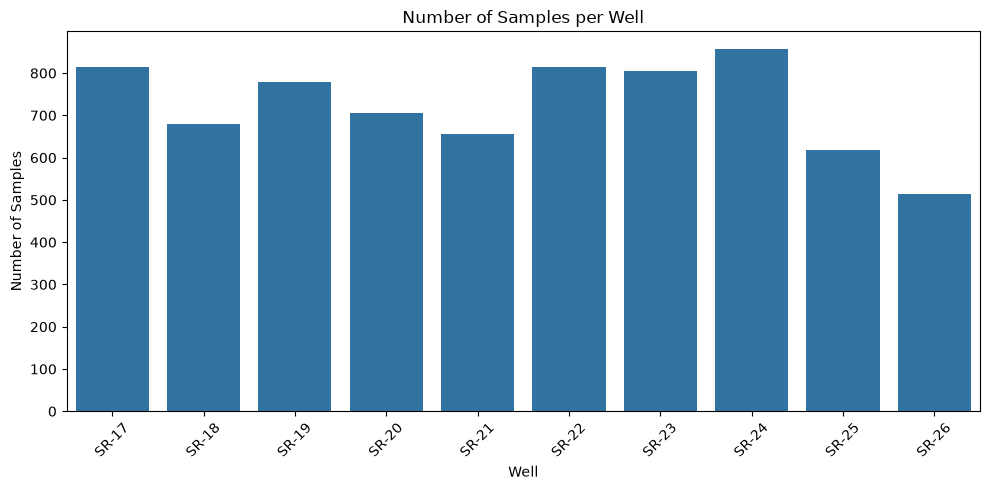

In [31]:
well_counts = df["Well"].value_counts().sort_index()
display(well_counts)
plt.figure(figsize=(10, 5))

sns.barplot(
    x=well_counts.index,
    y=well_counts.values
)

plt.xlabel("Well")
plt.ylabel("Number of Samples")
plt.title("Number of Samples per Well")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

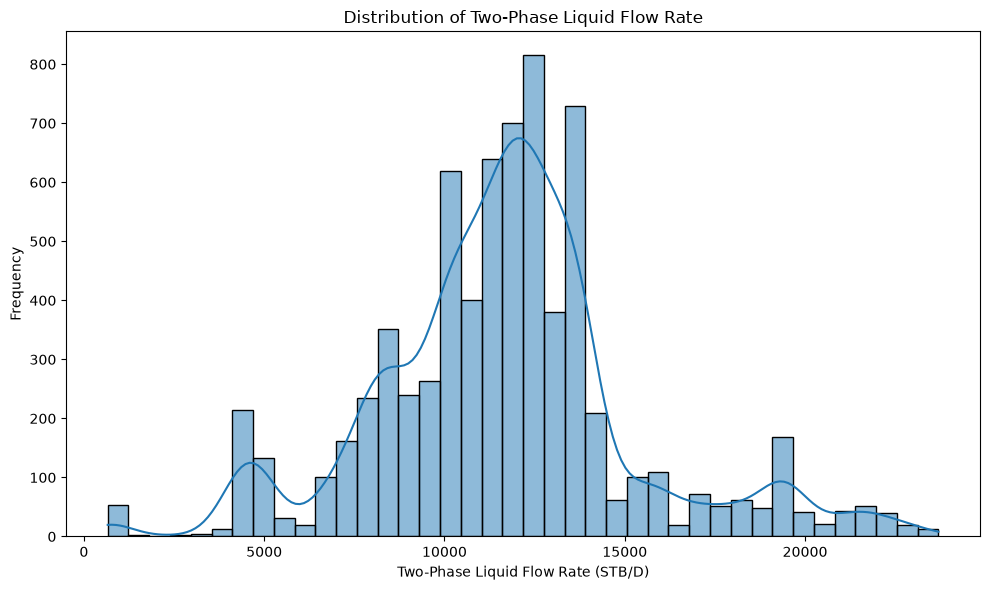

In [33]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="QL",
    bins=40,
    kde=True
)

plt.xlabel("Two-Phase Liquid Flow Rate (STB/D)")
plt.ylabel("Frequency")
plt.title("Distribution of Two-Phase Liquid Flow Rate")

plt.tight_layout()

plt.savefig(
    "../results/figures/ql_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

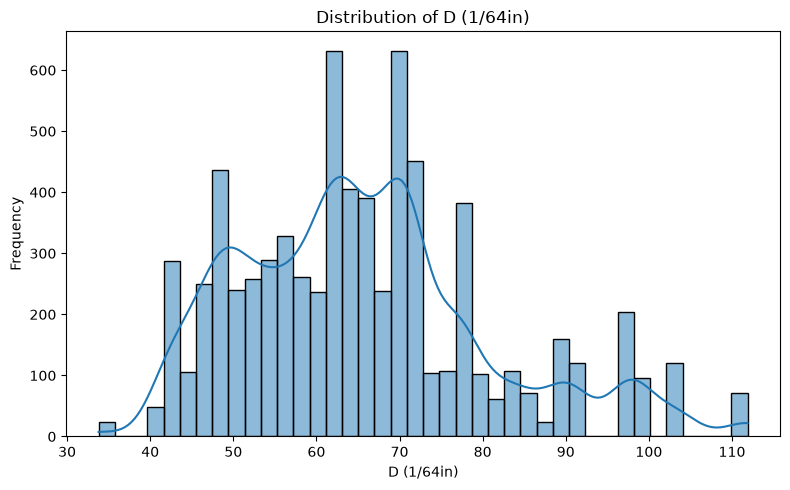

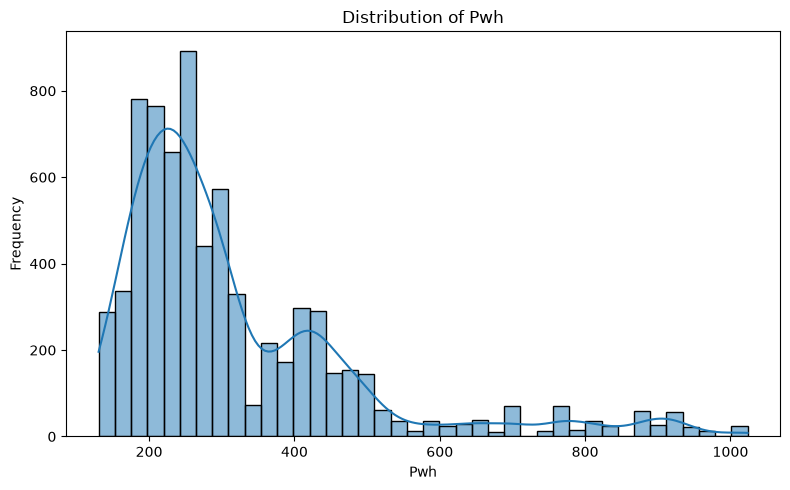

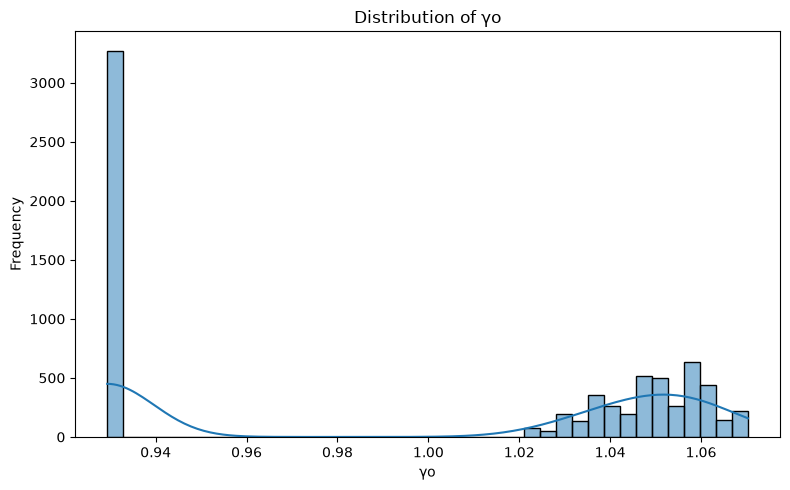

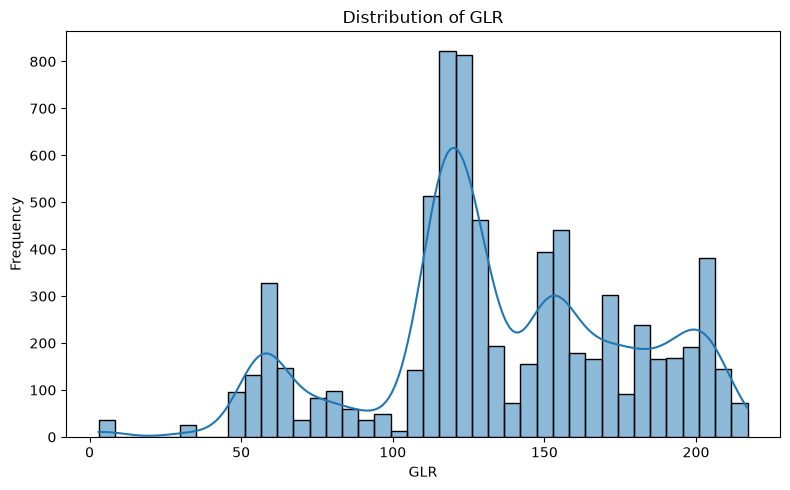

In [35]:
for feature in FEATURES:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        bins=40,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()

    safe_name = (
        feature
        .replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

    plt.savefig(
        f"../results/figures/distribution_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

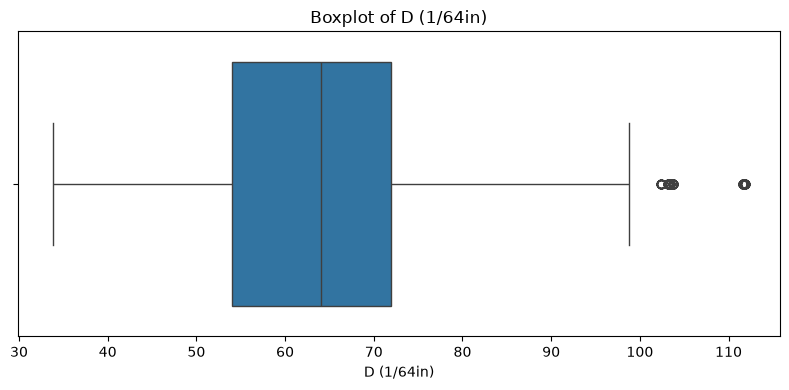

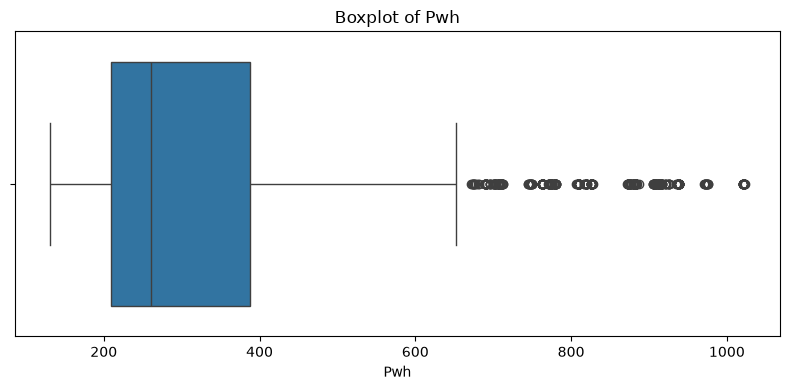

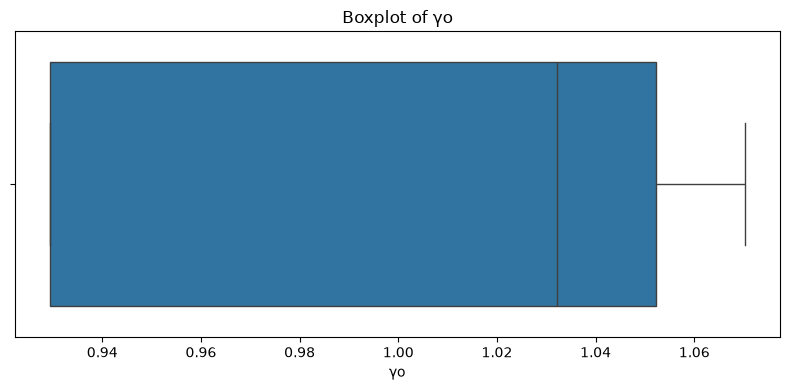

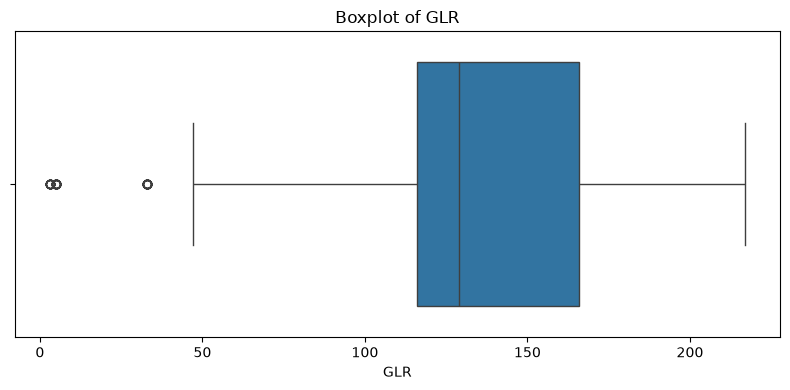

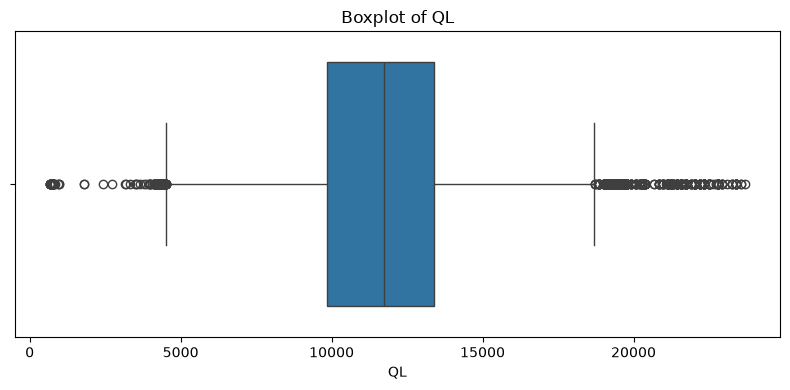

In [36]:
for feature in FEATURES + [TARGET]:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[feature]
    )

    plt.title(f"Boxplot of {feature}")

    plt.tight_layout()
    plt.show()

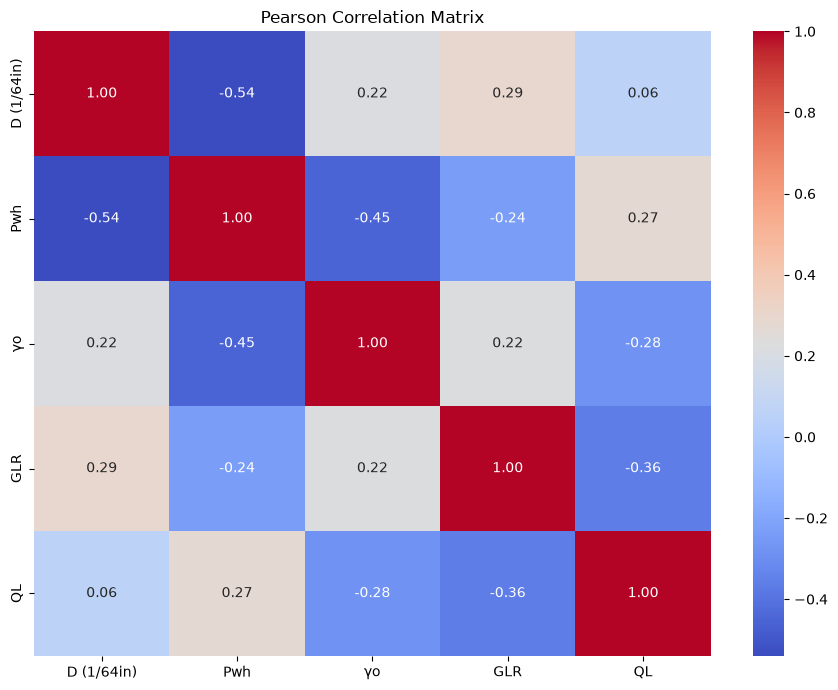

In [37]:
correlation = df[
    FEATURES + [TARGET]
].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Pearson Correlation Matrix")

plt.tight_layout()
plt.show()